
# EV-SPARK-Cover v1.3.1 — Benchmark Visuals

Notebook này được viết lại dựa trực tiếp trên cấu trúc thật của:

`v1_3_1-20260626T035228Z-3-001.zip`

Nguồn benchmark được khóa vào đúng file:

`v1_3_1/paper/tables/paper_all_methods_5pct.csv`

Notebook tạo:

1. Recovery performance  
2. Service distance  
3. Aggregate coverage  
4. Redundancy  
5. Benchmark table với giá trị tốt nhất được in đậm  

Mỗi chart nằm trong một cell riêng. Cell cuối cùng mới lưu toàn bộ output.


In [19]:
# ============================================================
# CELL 1 — CONFIG
# Chỉ sửa SOURCE_PATH nếu cần.
# Có thể trỏ tới:
#   1) folder đã giải nén
#   2) file ZIP gốc
# ============================================================

from pathlib import Path

SOURCE_PATH = Path(
    r"C:\Users\Admin\Desktop\DSP391m\data_dsp_final\dsp_ev\final_to_paper\v1_3_1-20260626T035228Z-3-001"
)

# Ví dụ nếu muốn đọc trực tiếp ZIP:
# SOURCE_PATH = Path(
#     r"C:\Users\Admin\Desktop\DSP391m\data_dsp_final\dsp_ev\final_to_paper\v1_3_1-20260626T035228Z-3-001.zip"
# )

EXPORT_DPI = 320
EXPORT_TRANSPARENT = False

OUTPUT_FOLDER_NAME = "EV_SPARK_Cover_Benchmark_Visuals"

OUTPUT_FILENAMES = {
    "recovery": "01_recovery_performance.pdf",
    "distance": "02_service_distance.pdf",
    "coverage": "03_aggregate_coverage.pdf",
    "redundancy": "04_redundancy.pdf",
    "table": "05_benchmark_table.pdf",
    # Hai figure ghép trực tiếp cho paper
    "paper_recovery_distance": "06_paper_recovery_distance.pdf",
    "paper_coverage_redundancy": "07_paper_coverage_redundancy.pdf",
}

# Bật chế độ export dành cho paper.
# - bỏ title dài bên trong chart
# - dùng nhãn ngắn B1...B6
# - tăng cỡ chữ / line width / hatch
# - giảm số value label để khi đặt vào paper vẫn đọc được ở 100% zoom
PAPER_MODE = True

print("SOURCE_PATH:", SOURCE_PATH)


SOURCE_PATH: C:\Users\Admin\Desktop\DSP391m\data_dsp_final\dsp_ev\final_to_paper\v1_3_1-20260626T035228Z-3-001


In [20]:
# ============================================================
# CELL 2 — LOAD EXACT BENCHMARK FILE
# Không dùng fallback và không quét nhầm CSV khác.
# ============================================================

import io
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPECTED_RELATIVE_PATH = Path(
    "v1_3_1/paper/tables/paper_all_methods_5pct.csv"
)

EXPECTED_COLUMNS = [
    "method",
    "heldout_temporal_demand_capture__mean",
    "normalized_heldout_capture__mean",
    "heldout_recall_2km__mean",
    "temporal_incremental_coverage__mean",
    "zone_jain__mean",
    "zone_gini__mean",
    "mean_service_distance_km__mean",
    "p95_service_distance_km__mean",
    "redundancy_jaccard__mean",
    "runtime_seconds__median",
]

METHOD_MAP = {
    "B1_random": "B1 Random",
    "B2_poi_density": "B2 POI density",
    "B3_temporal_rank": "B3 Demand rank",
    "B4_weighted_spatial_diversity": "B4 Spatial diversity",
    "B5_static_coverage": "B5 Static coverage",
    "B6_evspark_cover": "B6 EV-SPARK-Cover",
}

METHOD_ORDER = list(METHOD_MAP.values())
SHORT_LABELS = {
    "B1 Random": "B1",
    "B2 POI density": "B2",
    "B3 Demand rank": "B3",
    "B4 Spatial diversity": "B4",
    "B5 Static coverage": "B5",
    "B6 EV-SPARK-Cover": "B6",
}

METHOD_HATCHES = {
    "B1 Random": "...",
    "B2 POI density": "///",
    "B3 Demand rank": "ooo",
    "B4 Spatial diversity": "xxx",
    "B5 Static coverage": "---",
    "B6 EV-SPARK-Cover": "++",
}

METHOD_FACES = {
    "B1 Random": "white",
    "B2 POI density": "white",
    "B3 Demand rank": "white",
    "B4 Spatial diversity": "white",
    "B5 Static coverage": "white",
    "B6 EV-SPARK-Cover": "0.85",
}

def load_exact_benchmark(source_path: Path):
    source_path = Path(source_path)

    if source_path.is_file() and source_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(source_path, "r") as zf:
            zip_name = EXPECTED_RELATIVE_PATH.as_posix()
            if zip_name not in zf.namelist():
                raise FileNotFoundError(
                    f"Không tìm thấy {zip_name} trong ZIP."
                )
            with zf.open(zip_name) as f:
                raw = f.read()
                df = pd.read_csv(io.BytesIO(raw))
                benchmark_source = f"ZIP::{source_path}::{zip_name}"
                return df, benchmark_source

    if source_path.is_dir():
        csv_path = source_path / EXPECTED_RELATIVE_PATH
        if not csv_path.exists():
            raise FileNotFoundError(f"Không tìm thấy file: {csv_path}")
        df = pd.read_csv(csv_path)
        benchmark_source = str(csv_path)
        return df, benchmark_source

    raise FileNotFoundError(
        f"SOURCE_PATH không hợp lệ hoặc không tồn tại: {source_path}"
    )

raw_df, BENCHMARK_SOURCE = load_exact_benchmark(SOURCE_PATH)

missing_columns = [c for c in EXPECTED_COLUMNS if c not in raw_df.columns]
if missing_columns:
    raise ValueError(
        "Benchmark file thiếu cột bắt buộc: " + ", ".join(missing_columns)
    )

benchmark_df = raw_df[EXPECTED_COLUMNS].copy()
benchmark_df["method"] = benchmark_df["method"].map(METHOD_MAP)

if benchmark_df["method"].isna().any():
    unknown = raw_df.loc[benchmark_df["method"].isna(), "method"].tolist()
    raise ValueError(f"Phát hiện method không map được: {unknown}")

benchmark_df = benchmark_df.rename(columns={
    "heldout_temporal_demand_capture__mean": "capture",
    "normalized_heldout_capture__mean": "normalized_capture",
    "heldout_recall_2km__mean": "recall_at_2km",
    "temporal_incremental_coverage__mean": "coverage",
    "zone_jain__mean": "jain",
    "zone_gini__mean": "gini",
    "mean_service_distance_km__mean": "mean_distance_km",
    "p95_service_distance_km__mean": "p95_distance_km",
    "redundancy_jaccard__mean": "redundancy",
    "runtime_seconds__median": "runtime_seconds",
})

benchmark_df["method"] = pd.Categorical(
    benchmark_df["method"],
    categories=METHOD_ORDER,
    ordered=True,
)
benchmark_df = benchmark_df.sort_values("method").reset_index(drop=True)
benchmark_df["short_method"] = benchmark_df["method"].map(SHORT_LABELS)

OUTPUT_DIR = (
    SOURCE_PATH.parent / OUTPUT_FOLDER_NAME
    if SOURCE_PATH.is_file()
    else SOURCE_PATH.parent / OUTPUT_FOLDER_NAME
)

FIGURES = {}

# ---------------- PAPER STYLE HELPERS ----------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "hatch.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def paper_xticklabels(df):
    return df["short_method"] if PAPER_MODE else df["method"]

def maybe_title(ax, title):
    if not PAPER_MODE:
        ax.set_title(title, pad=10)

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.20, linewidth=0.6)
    ax.tick_params(axis="x", pad=2)

def emphasize_selected_bars(bars, labels):
    for b, m in zip(bars, labels):
        if m == "B6 EV-SPARK-Cover":
            b.set_linewidth(1.6)
        elif m == "B5 Static coverage":
            b.set_linewidth(1.3)

def label_only_key_bars(ax, bars, values, methods, fmt):
    # Chỉ gắn nhãn cho B5 và B6 để chart đỡ rối trong paper.
    for bar, v, m in zip(bars, values, methods):
        if (not PAPER_MODE) or m in {"B5 Static coverage", "B6 EV-SPARK-Cover"}:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                fmt(v),
                ha="center",
                va="bottom",
                fontsize=8 if PAPER_MODE else 9,
            )

print("BENCHMARK_SOURCE:", BENCHMARK_SOURCE)
display(benchmark_df)


BENCHMARK_SOURCE: C:\Users\Admin\Desktop\DSP391m\data_dsp_final\dsp_ev\final_to_paper\v1_3_1-20260626T035228Z-3-001\v1_3_1\paper\tables\paper_all_methods_5pct.csv


,method,capture,normalized_capture,recall_at_2km,coverage,jain,gini,mean_distance_km,p95_distance_km,redundancy,runtime_seconds,short_method
0,B1 Random,0.059761,0.160893,0.161921,0.091040,0.273420,0.755113,3.880965,15.431464,0.026508,0.000520,B1
1,B2 POI density,0.034127,0.069282,0.064065,0.101426,0.240516,0.784415,6.267384,23.801126,0.348805,0.000813,B2
2,B3 Demand rank,0.036371,0.077701,0.068651,0.130493,0.240966,0.784066,5.609837,23.196485,0.295078,0.000809,B3
3,B4 Spatial diversity,0.040874,0.200107,0.124277,0.035772,0.285070,0.744894,3.191158,8.936394,0.000512,0.003092,B4
4,B5 Static coverage,0.058482,0.121580,0.135777,0.136525,0.254488,0.772026,4.977572,20.973426,0.208244,0.068753,B5
5,B6 EV-SPARK-Cover,0.126875,0.537969,0.292638,0.123118,0.292504,0.737985,2.881092,11.839939,0.082043,0.061273,B6


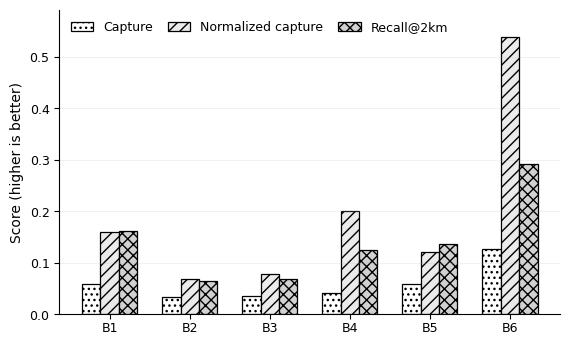

In [21]:
# ============================================================
# CELL 3 — CHART 1: RECOVERY PERFORMANCE
# Capture, Normalized Capture, Recall@2km
# Higher is better.
# ============================================================

metrics = [
    ("capture", "Capture"),
    ("normalized_capture", "Normalized capture"),
    ("recall_at_2km", "Recall@2km"),
]

x = np.arange(len(benchmark_df))
width = 0.23

fig_recovery, ax = plt.subplots(figsize=(5.6, 3.35) if PAPER_MODE else (13.5, 6.8))

METRIC_HATCHES = {
    "Capture": "...",
    "Normalized capture": "///",
    "Recall@2km": "xxx",
}

METRIC_FACES = {
    "Capture": "white",
    "Normalized capture": "0.92",
    "Recall@2km": "0.82",
}

all_bars = []
for i, (column, label) in enumerate(metrics):
    bars = ax.bar(
        x + (i - 1) * width,
        benchmark_df[column],
        width=width,
        label=label,
        facecolor=METRIC_FACES[label],
        edgecolor="black",
        linewidth=0.9,
        hatch=METRIC_HATCHES[label],
    )
    all_bars.append((bars, column))


maybe_title(ax, "Recovery Performance Across Benchmark Methods")
ax.set_ylabel("Score (higher is better)")
ax.set_xticks(x)
ax.set_xticklabels(paper_xticklabels(benchmark_df), rotation=0 if PAPER_MODE else 18, ha="center" if PAPER_MODE else "right")
style_axes(ax)
ax.legend(ncol=3, loc="upper left", frameon=False, handlelength=1.8, columnspacing=1.2)
ax.set_ylim(0, benchmark_df[[m[0] for m in metrics]].to_numpy().max() * (1.10 if PAPER_MODE else 1.22))

fig_recovery.tight_layout(pad=0.35)
FIGURES["recovery"] = fig_recovery
plt.show()


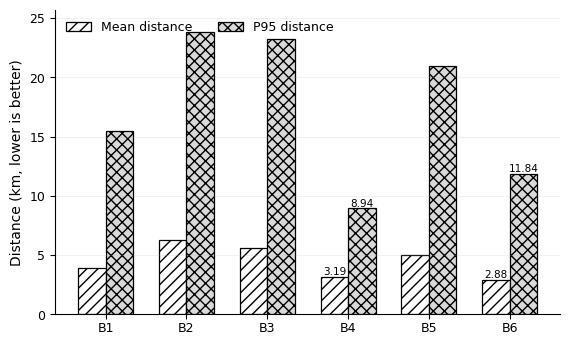

In [22]:
# ============================================================
# CELL 4 — CHART 2: SERVICE DISTANCE
# Mean distance và P95 distance
# Lower is better.
# ============================================================

x = np.arange(len(benchmark_df))
width = 0.34

fig_distance, ax = plt.subplots(figsize=(5.6, 3.35) if PAPER_MODE else (13.5, 6.8))

bars_mean = ax.bar(
    x - width / 2,
    benchmark_df["mean_distance_km"],
    width=width,
    label="Mean distance",
    facecolor="white",
    edgecolor="black",
    linewidth=0.9,
    hatch="///",
)
bars_p95 = ax.bar(
    x + width / 2,
    benchmark_df["p95_distance_km"],
    width=width,
    label="P95 distance",
    facecolor="0.85",
    edgecolor="black",
    linewidth=0.9,
    hatch="xxx",
)

for bars, col in [(bars_mean, "mean_distance_km"), (bars_p95, "p95_distance_km")]:
    vals = benchmark_df[col].tolist()
    methods = benchmark_df["method"].tolist()
    for bar, v, m in zip(bars, vals, methods):
        if (not PAPER_MODE) or (PAPER_MODE and m in {"B4 Spatial diversity", "B6 EV-SPARK-Cover"}):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{v:.2f}",
                ha="center", va="bottom",
                fontsize=7.5 if PAPER_MODE else 9,
            )

maybe_title(ax, "Service Distance Across Benchmark Methods")
ax.set_ylabel("Distance (km, lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(paper_xticklabels(benchmark_df), rotation=0 if PAPER_MODE else 18, ha="center" if PAPER_MODE else "right")
style_axes(ax)
ax.legend(ncol=2, loc="upper left", frameon=False)
ax.set_ylim(0, benchmark_df[["mean_distance_km", "p95_distance_km"]].to_numpy().max() * (1.08 if PAPER_MODE else 1.18))

fig_distance.tight_layout(pad=0.35)
FIGURES["distance"] = fig_distance
plt.show()


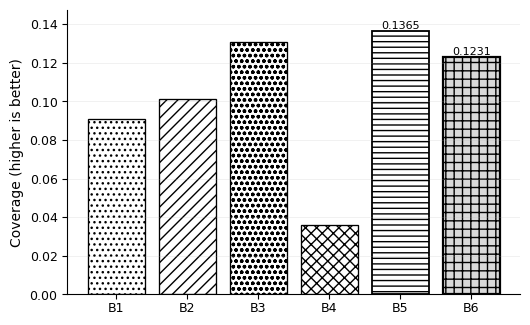

In [23]:
# ============================================================
# CELL 5 — CHART 3: AGGREGATE COVERAGE
# Higher is better.
# ============================================================

fig_coverage, ax = plt.subplots(figsize=(5.2, 3.15) if PAPER_MODE else (12.5, 6.3))

methods = benchmark_df["method"].tolist()

bars = ax.bar(
    benchmark_df["short_method"] if PAPER_MODE else methods,
    benchmark_df["coverage"],
    color=[METHOD_FACES[m] for m in methods],
    edgecolor="black",
    linewidth=0.95,
)

for bar, method in zip(bars, methods):
    bar.set_hatch(METHOD_HATCHES[method])

emphasize_selected_bars(bars, methods)
label_only_key_bars(ax, bars, benchmark_df["coverage"].tolist(), methods, lambda v: f"{v:.4f}")

maybe_title(ax, "Aggregate Incremental Coverage")
ax.set_ylabel("Coverage (higher is better)")
if not PAPER_MODE:
    ax.tick_params(axis="x", rotation=18)
    for label in ax.get_xticklabels():
        label.set_ha("right")
style_axes(ax)
ax.set_ylim(0, benchmark_df["coverage"].max() * (1.08 if PAPER_MODE else 1.20))

fig_coverage.tight_layout(pad=0.35)
FIGURES["coverage"] = fig_coverage
plt.show()


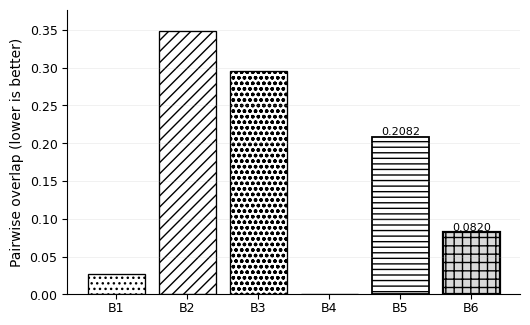

In [24]:
# ============================================================
# CELL 6 — CHART 4: REDUNDANCY
# Lower is better.
# ============================================================

fig_redundancy, ax = plt.subplots(figsize=(5.2, 3.15) if PAPER_MODE else (12.5, 6.3))

methods = benchmark_df["method"].tolist()

bars = ax.bar(
    benchmark_df["short_method"] if PAPER_MODE else methods,
    benchmark_df["redundancy"],
    color=[METHOD_FACES[m] for m in methods],
    edgecolor="black",
    linewidth=0.95,
)

for bar, method in zip(bars, methods):
    bar.set_hatch(METHOD_HATCHES[method])

emphasize_selected_bars(bars, methods)
label_only_key_bars(ax, bars, benchmark_df["redundancy"].tolist(), methods, lambda v: f"{v:.4f}")

maybe_title(ax, "Selected-Site Redundancy")
ax.set_ylabel("Pairwise overlap (lower is better)")
if not PAPER_MODE:
    ax.tick_params(axis="x", rotation=18)
    for label in ax.get_xticklabels():
        label.set_ha("right")
style_axes(ax)
ax.set_ylim(0, benchmark_df["redundancy"].max() * (1.08 if PAPER_MODE else 1.18))

fig_redundancy.tight_layout(pad=0.35)
FIGURES["redundancy"] = fig_redundancy
plt.show()


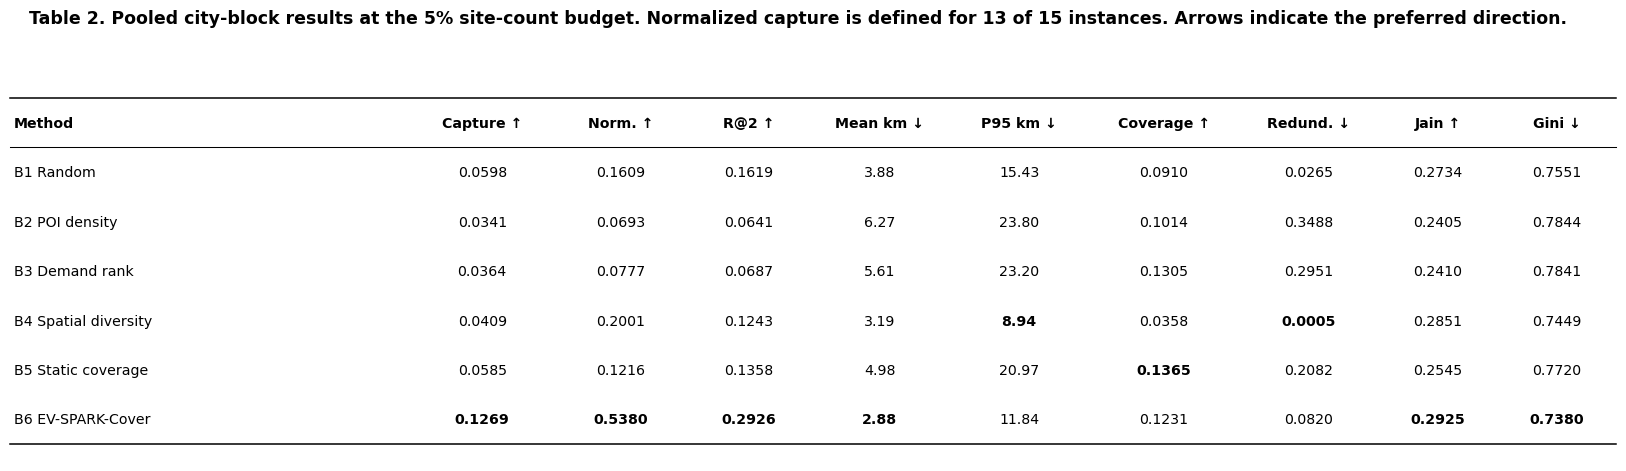

In [25]:
# ============================================================
# CELL 7 — BENCHMARK TABLE
# Tự động bold:
# - MAX: Capture, Norm., R@2, Coverage, Jain
# - MIN: Mean km, P95 km, Redundancy, Gini
# ============================================================

table_df = benchmark_df.copy()

display_df = pd.DataFrame({
    "Method": table_df["method"],
    "Capture ↑": table_df["capture"].map(lambda x: f"{x:.4f}"),
    "Norm. ↑": table_df["normalized_capture"].map(lambda x: f"{x:.4f}"),
    "R@2 ↑": table_df["recall_at_2km"].map(lambda x: f"{x:.4f}"),
    "Mean km ↓": table_df["mean_distance_km"].map(lambda x: f"{x:.2f}"),
    "P95 km ↓": table_df["p95_distance_km"].map(lambda x: f"{x:.2f}"),
    "Coverage ↑": table_df["coverage"].map(lambda x: f"{x:.4f}"),
    "Redund. ↓": table_df["redundancy"].map(lambda x: f"{x:.4f}"),
    "Jain ↑": table_df["jain"].map(lambda x: f"{x:.4f}"),
    "Gini ↓": table_df["gini"].map(lambda x: f"{x:.4f}"),
})

higher_is_better = {
    "Capture ↑": "capture",
    "Norm. ↑": "normalized_capture",
    "R@2 ↑": "recall_at_2km",
    "Coverage ↑": "coverage",
    "Jain ↑": "jain",
}

lower_is_better = {
    "Mean km ↓": "mean_distance_km",
    "P95 km ↓": "p95_distance_km",
    "Redund. ↓": "redundancy",
    "Gini ↓": "gini",
}

# Tăng chiều rộng figure vì thêm 2 cột
fig_table, ax = plt.subplots(figsize=(17.8, 4.8))
ax.axis("off")

caption = (
    "Table 2. Pooled city-block results at the 5% site-count budget. "
    "Normalized capture is defined for 13 of 15 instances. "
    "Arrows indicate the preferred direction."
)

ax.text(
    0.0,
    1.04,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=12.5,
    fontweight="bold",
    wrap=True,
)

# Cột Method rộng hơn, các cột số hẹp vừa phải
col_widths = [
    0.235,  # Method
    0.085,  # Capture
    0.078,  # Norm.
    0.072,  # R@2
    0.082,  # Mean km
    0.082,  # P95 km
    0.088,  # Coverage
    0.082,  # Redund.
    0.070,  # Jain
    0.070,  # Gini
]

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=col_widths,

    # x âm nhẹ để kéo bảng sang trái hơn
    bbox=[-0.012, 0.04, 1.02, 0.83],
)

table.auto_set_font_size(False)
table.set_fontsize(10.2)
table.scale(1.0, 1.38)

n_rows = len(display_df)
n_cols = len(display_df.columns)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor("white")
    cell.set_edgecolor("white")
    cell.set_linewidth(0.0)

    # Giảm khoảng trống trong từng ô
    cell.PAD = 0.025

    if row == 0:
        cell.set_text_props(weight="bold")

    # Căn trái toàn bộ cột Method, kể cả header
    if col == 0:
        cell.set_text_props(ha="left")
        cell.PAD = 0.01

# In đậm giá trị tốt nhất với metric càng cao càng tốt
for display_col, numeric_col in higher_is_better.items():
    best_value = table_df[numeric_col].max()

    # Hỗ trợ trường hợp nhiều method đồng hạng
    best_rows = table_df.index[
        np.isclose(table_df[numeric_col], best_value)
    ]

    col_idx = display_df.columns.get_loc(display_col)

    for best_row in best_rows:
        table[(best_row + 1, col_idx)].set_text_props(weight="bold")

# In đậm giá trị tốt nhất với metric càng thấp càng tốt
for display_col, numeric_col in lower_is_better.items():
    best_value = table_df[numeric_col].min()

    best_rows = table_df.index[
        np.isclose(table_df[numeric_col], best_value)
    ]

    col_idx = display_df.columns.get_loc(display_col)

    for best_row in best_rows:
        table[(best_row + 1, col_idx)].set_text_props(weight="bold")

# Vẽ 3 đường ngang theo phong cách bảng paper:
# 1. phía trên header
# 2. phía dưới header
# 3. phía dưới bảng
fig_table.canvas.draw()
renderer = fig_table.canvas.get_renderer()

left = table[(0, 0)].get_window_extent(renderer).x0
right = table[(0, n_cols - 1)].get_window_extent(renderer).x1
header_top = table[(0, 0)].get_window_extent(renderer).y1
header_bottom = table[(0, 0)].get_window_extent(renderer).y0
table_bottom = table[(n_rows, 0)].get_window_extent(renderer).y0

inv = ax.transAxes.inverted()

x0, y_header_top = inv.transform((left, header_top))
x1, _ = inv.transform((right, header_top))
_, y_header_bottom = inv.transform((left, header_bottom))
_, y_table_bottom = inv.transform((left, table_bottom))

ax.plot(
    [x0, x1],
    [y_header_top, y_header_top],
    color="black",
    linewidth=1.1,
    transform=ax.transAxes,
    clip_on=False,
)

ax.plot(
    [x0, x1],
    [y_header_bottom, y_header_bottom],
    color="black",
    linewidth=0.75,
    transform=ax.transAxes,
    clip_on=False,
)

ax.plot(
    [x0, x1],
    [y_table_bottom, y_table_bottom],
    color="black",
    linewidth=1.1,
    transform=ax.transAxes,
    clip_on=False,
)

fig_table.tight_layout()
FIGURES["table"] = fig_table
plt.show()

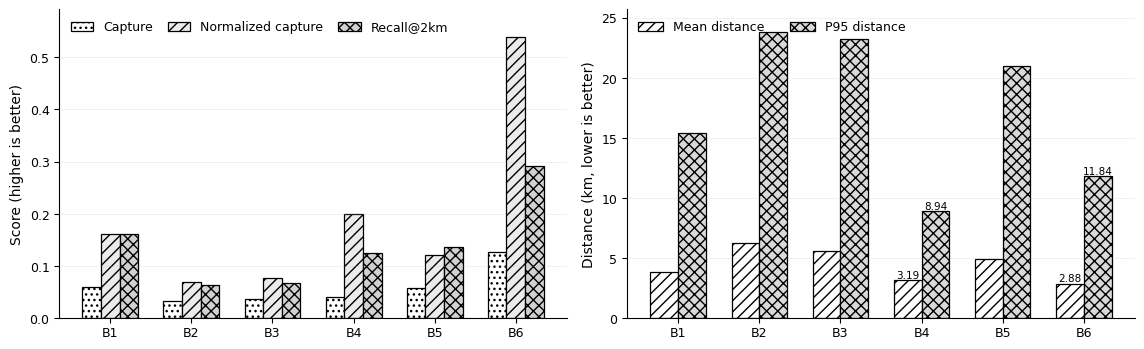

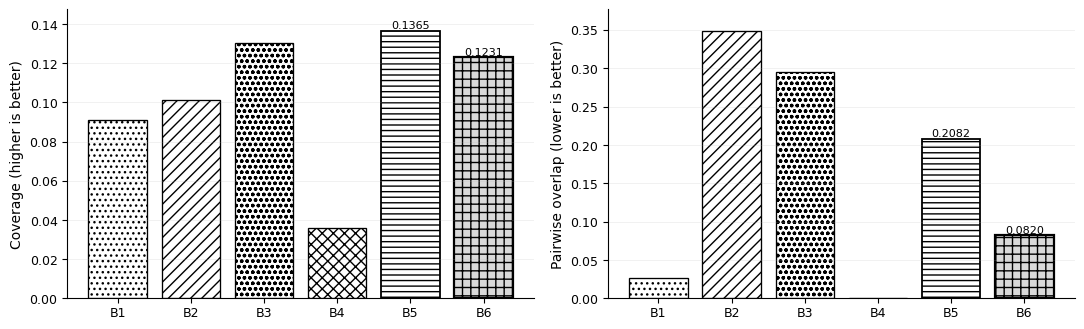

In [26]:
# ============================================================
# CELL 8 — PAPER COMPOSITE FIGURES
# Tạo 2 figure ghép sẵn để chèn vào LaTeX cho dễ đọc ở 100% zoom.
# ============================================================

# Figure A: Recovery + Distance
fig_paper_rd, axes = plt.subplots(1, 2, figsize=(11.4, 3.45))

ax = axes[0]
metrics = [("capture", "Capture"), ("normalized_capture", "Normalized capture"), ("recall_at_2km", "Recall@2km")]
x = np.arange(len(benchmark_df))
width = 0.23
for i, (column, label) in enumerate(metrics):
    bars = ax.bar(
        x + (i - 1) * width,
        benchmark_df[column],
        width=width,
        label=label,
        facecolor={"Capture":"white","Normalized capture":"0.92","Recall@2km":"0.82"}[label],
        edgecolor="black",
        linewidth=0.9,
        hatch={"Capture":"...","Normalized capture":"///","Recall@2km":"xxx"}[label],
    )
ax.set_ylabel("Score (higher is better)")
ax.set_xticks(x)
ax.set_xticklabels(benchmark_df["short_method"])
style_axes(ax)
ax.legend(ncol=3, loc="upper left", frameon=False, handlelength=1.8, columnspacing=1.2)
ax.set_ylim(0, benchmark_df[[m[0] for m in metrics]].to_numpy().max()*1.10)

ax = axes[1]
width = 0.34
bars_mean = ax.bar(x - width / 2, benchmark_df["mean_distance_km"], width=width, label="Mean distance", facecolor="white", edgecolor="black", linewidth=0.9, hatch="///")
bars_p95 = ax.bar(x + width / 2, benchmark_df["p95_distance_km"], width=width, label="P95 distance", facecolor="0.85", edgecolor="black", linewidth=0.9, hatch="xxx")
for bars, col in [(bars_mean, "mean_distance_km"), (bars_p95, "p95_distance_km")]:
    for bar, v, m in zip(bars, benchmark_df[col], benchmark_df["method"]):
        if m in {"B4 Spatial diversity", "B6 EV-SPARK-Cover"}:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)
ax.set_ylabel("Distance (km, lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(benchmark_df["short_method"])
style_axes(ax)
ax.legend(ncol=2, loc="upper left", frameon=False)
ax.set_ylim(0, benchmark_df[["mean_distance_km", "p95_distance_km"]].to_numpy().max()*1.08)

fig_paper_rd.tight_layout(pad=0.55, w_pad=1.1)
FIGURES["paper_recovery_distance"] = fig_paper_rd
plt.show()

# Figure B: Coverage + Redundancy
fig_paper_cr, axes = plt.subplots(1, 2, figsize=(10.8, 3.25))

ax = axes[0]
bars = ax.bar(benchmark_df["short_method"], benchmark_df["coverage"], color=[METHOD_FACES[m] for m in benchmark_df["method"]], edgecolor="black", linewidth=0.95)
for bar, method in zip(bars, benchmark_df["method"]):
    bar.set_hatch(METHOD_HATCHES[method])
emphasize_selected_bars(bars, benchmark_df["method"].tolist())
label_only_key_bars(ax, bars, benchmark_df["coverage"].tolist(), benchmark_df["method"].tolist(), lambda v: f"{v:.4f}")
ax.set_ylabel("Coverage (higher is better)")
style_axes(ax)
ax.set_ylim(0, benchmark_df["coverage"].max()*1.08)

ax = axes[1]
bars = ax.bar(benchmark_df["short_method"], benchmark_df["redundancy"], color=[METHOD_FACES[m] for m in benchmark_df["method"]], edgecolor="black", linewidth=0.95)
for bar, method in zip(bars, benchmark_df["method"]):
    bar.set_hatch(METHOD_HATCHES[method])
emphasize_selected_bars(bars, benchmark_df["method"].tolist())
label_only_key_bars(ax, bars, benchmark_df["redundancy"].tolist(), benchmark_df["method"].tolist(), lambda v: f"{v:.4f}")
ax.set_ylabel("Pairwise overlap (lower is better)")
style_axes(ax)
ax.set_ylim(0, benchmark_df["redundancy"].max()*1.08)

fig_paper_cr.tight_layout(pad=0.55, w_pad=1.2)
FIGURES["paper_coverage_redundancy"] = fig_paper_cr
plt.show()


In [27]:

# ============================================================
# CELL 8 — FINAL SAVE
# Lưu 4 charts + 1 table vào folder cùng cấp SOURCE_PATH.
# ============================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_files = []

for key, figure in FIGURES.items():
    if key not in OUTPUT_FILENAMES:
        raise KeyError(f"Thiếu tên file cho figure: {key}")

    out_file = OUTPUT_DIR / OUTPUT_FILENAMES[key]

    figure.savefig(
        out_file,
        dpi=EXPORT_DPI,
        bbox_inches="tight",
        transparent=EXPORT_TRANSPARENT,
        facecolor="white",
    )

    saved_files.append(out_file)

csv_file = OUTPUT_DIR / "benchmark_values_used.csv"
benchmark_df.to_csv(csv_file, index=False)
saved_files.append(csv_file)

audit_file = OUTPUT_DIR / "benchmark_build_audit.txt"

audit_text = (
    f"SOURCE_PATH={SOURCE_PATH}\n"
    f"BENCHMARK_SOURCE={BENCHMARK_SOURCE}\n"
    f"OUTPUT_DIR={OUTPUT_DIR}\n"
    f"EXPORT_DPI={EXPORT_DPI}\n"
    f"ROW_COUNT={len(benchmark_df)}\n"
    f"METHODS={benchmark_df['method'].tolist()}\n"
)

audit_file.write_text(audit_text, encoding="utf-8")
saved_files.append(audit_file)

print("Đã lưu output tại:")
print(OUTPUT_DIR)

for file in saved_files:
    print(" -", file.name)


Đã lưu output tại:
C:\Users\Admin\Desktop\DSP391m\data_dsp_final\dsp_ev\final_to_paper\EV_SPARK_Cover_Benchmark_Visuals
 - 01_recovery_performance.pdf
 - 02_service_distance.pdf
 - 03_aggregate_coverage.pdf
 - 04_redundancy.pdf
 - 05_benchmark_table.pdf
 - 06_paper_recovery_distance.pdf
 - 07_paper_coverage_redundancy.pdf
 - benchmark_values_used.csv
 - benchmark_build_audit.txt
